# Задание 2

## Визуальный анализ данных

### *Цель работы:* изучить программные средства, используемые для визуализации наборов данных.

Проанализируем датасет **blood**.  Набор данных содержит информацию о донорах и выполненных ими трансфузиях до марта 2007 г. включительно. Целью исследования является построение прогноза сдачи донором крови в марте 2007 г. Полученный результат позволяет оценить вероятность посещения донором центра сдачи крови в дальнейшем и относится к задачам бинарной классификации. В исследовании используется база данных доноров медицинского центра города Синьчжу на Тайване. Из базы данных медицинского центра случайным образом были выбраны 748 доноров для анализа.

**Атрибуты:**

• *Recency* – количество месяцев с момента последней сдачи крови донором;

• *Frequency* – общее количество трансфузий донора;

• *Monetary* – количество сданной донором крови в куб. см.;

• *Time* – количество месяцев с момента первого донорства;

• *Class* – целевая переменная прогноза трансфузии.

# 1. Импортируйте необходимые библиотеки

In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

# 2. Импортируйте набор данных из файла blood.сsv и поместите его в объект DataFrame

In [7]:
df = pd.read_csv("blood.csv")

# 3. Выведите 12 первых строк

In [8]:
df.head(12)

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
5,4,4,1000,4,0
6,2,7,1750,14,1
7,1,12,3000,35,0
8,2,9,2250,22,1
9,5,46,11500,98,1


# 4. Получите сводную информацию по датафрейму

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Class      748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


# 5. Визуализация количественных признаков

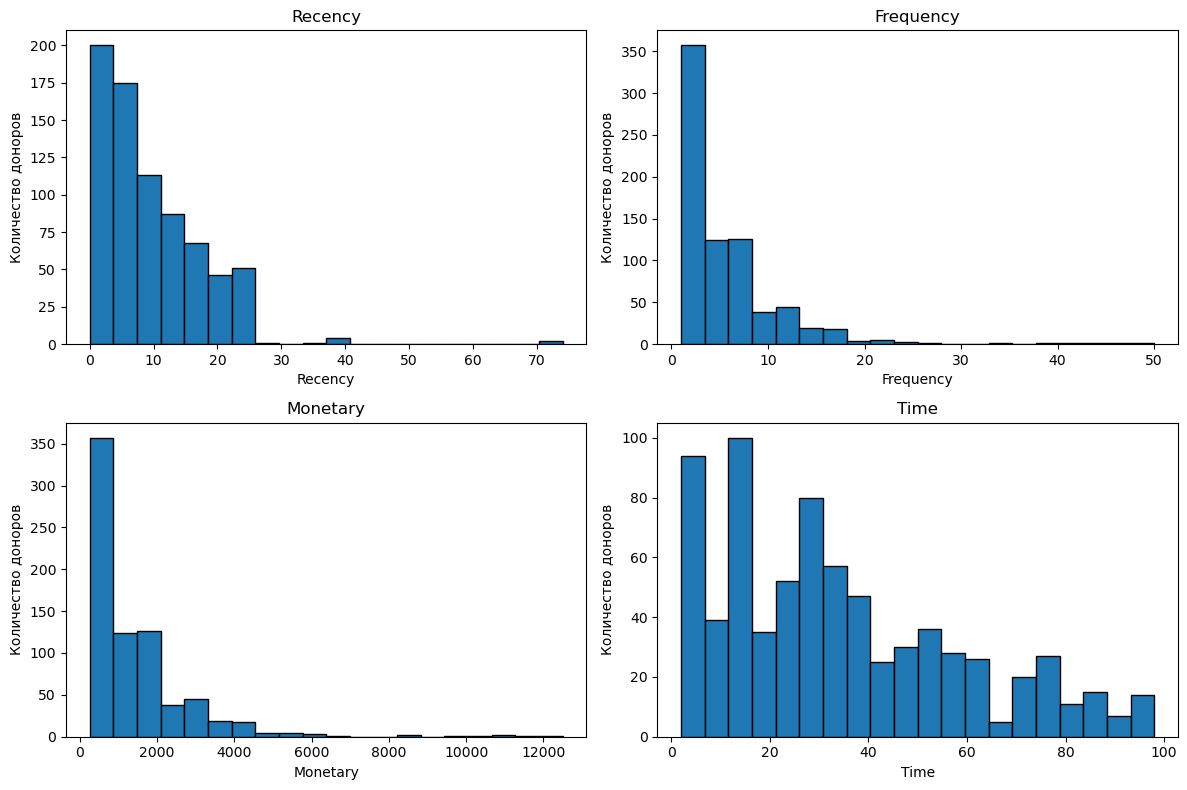

In [28]:
numeric_cols = ['Recency', 'Frequency', 'Monetary', 'Time']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Количество доноров")

plt.tight_layout()
plt.show()

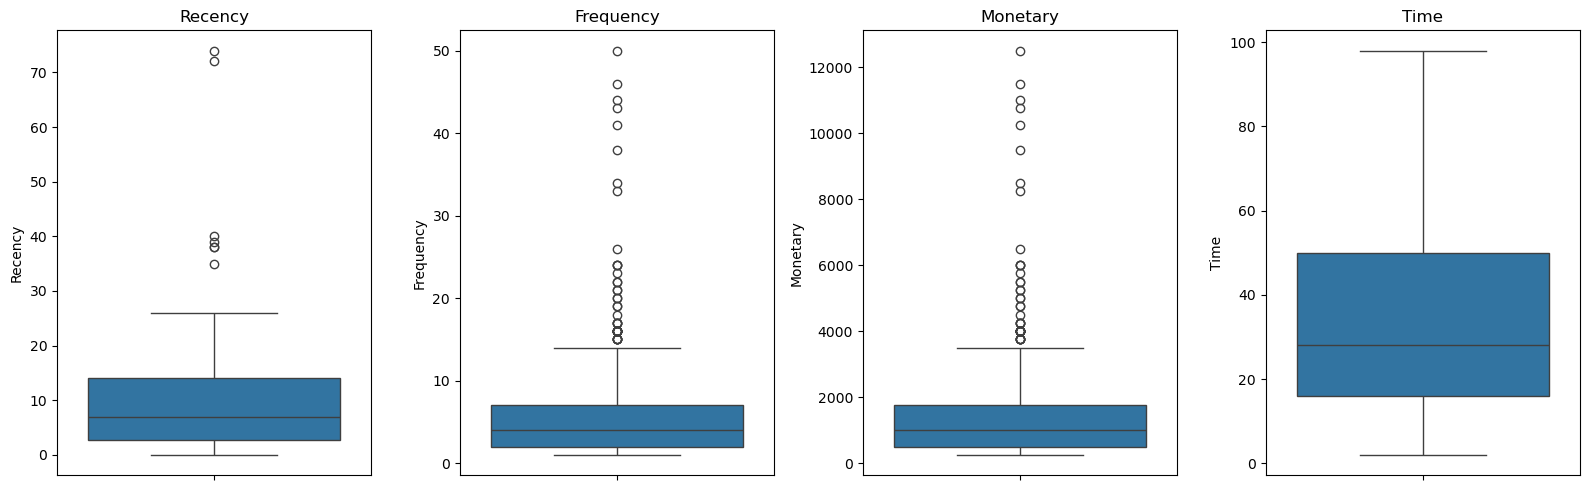

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

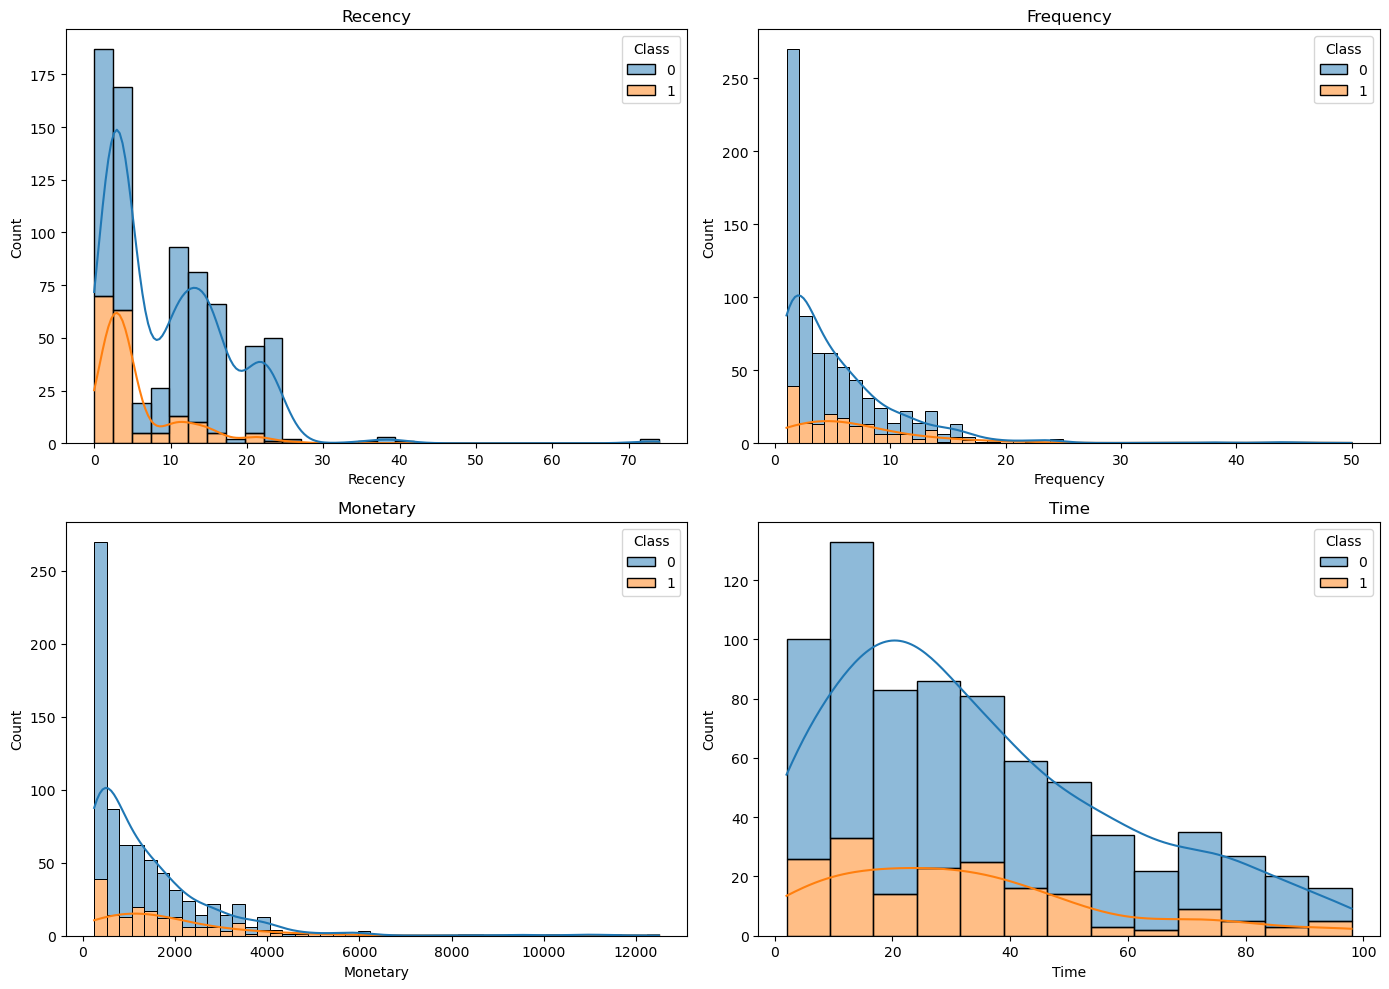

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        hue='Class',
        kde=True,
        ax=axes[i],
        multiple="stack"
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# 6. Визуализация категориальных признаков

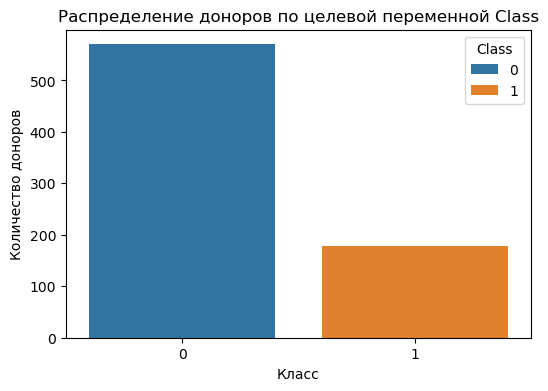

In [31]:
plt.figure(figsize=(6, 4))
plt.title("Распределение доноров по целевой переменной Class")
sns.countplot(x='Class', hue='Class', data=df)
plt.xlabel("Класс")
plt.ylabel("Количество доноров")
plt.show()

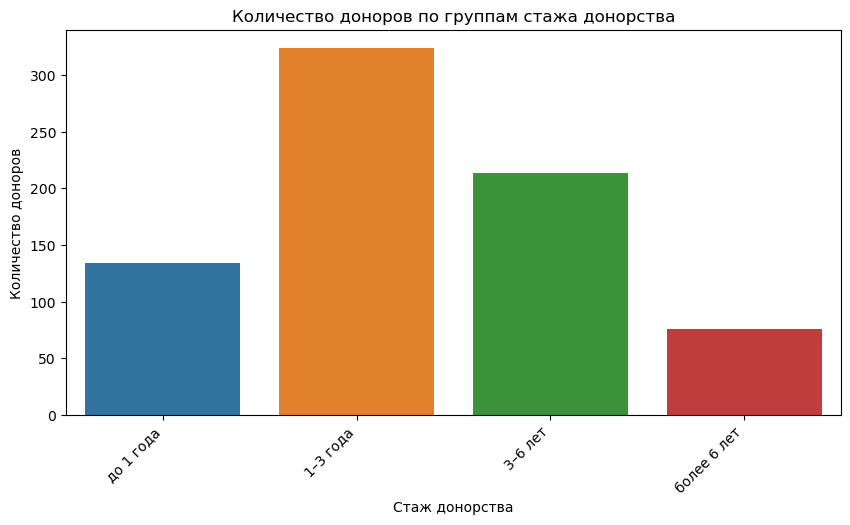

In [32]:
df['Time_group'] = pd.cut(
    df['Time'],
    bins=[0, 12, 36, 72, df['Time'].max()],
    labels=['до 1 года', '1–3 года', '3–6 лет', 'более 6 лет']
)

fig = plt.subplots(figsize=(10, 5))
sns.countplot(
    data=df[df['Time_group'].notna()],
    x='Time_group',
    hue='Time_group'
)
plt.title("Количество доноров по группам стажа донорства")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Стаж донорства")
plt.ylabel("Количество доноров")
plt.show()

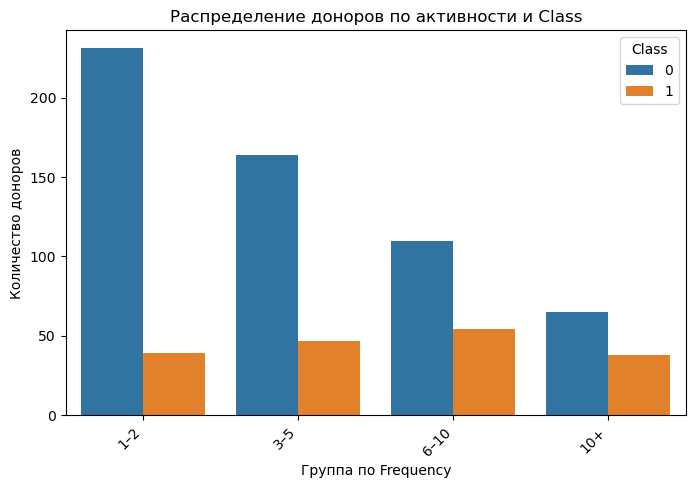

In [21]:
df['Freq_group'] = pd.cut(
    df['Frequency'],
    bins=[0, 2, 5, 10, df['Frequency'].max()],
    labels=['1–2', '3–5', '6–10', '10+']
)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df[df['Freq_group'].notna()],
    x='Freq_group',
    hue='Class'
)

plt.title("Распределение доноров по активности и Class")
plt.xlabel("Группа по Frequency")
plt.ylabel("Количество доноров")
plt.xticks(rotation=45, ha='right')
plt.show()

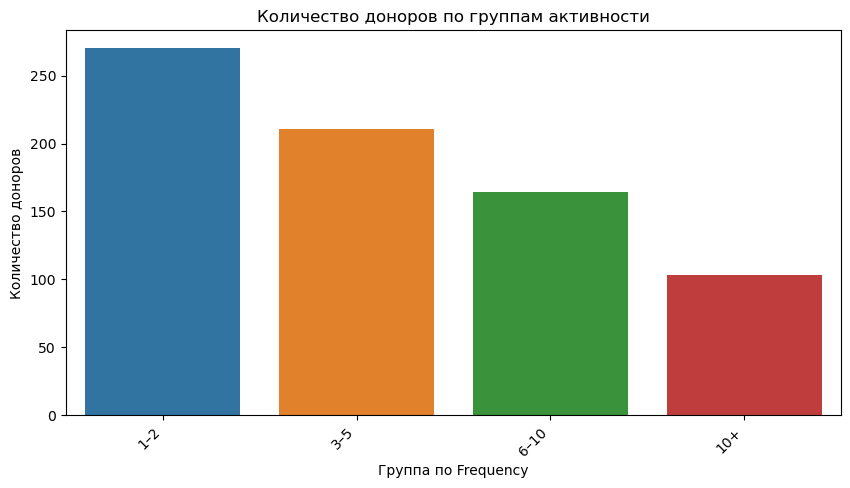

In [33]:
df['Freq_group'] = pd.cut(
    df['Frequency'],
    bins=[0, 2, 5, 10, df['Frequency'].max()],
    labels=['1–2', '3–5', '6–10', '10+']
)

fig = plt.subplots(figsize=(10, 5))
sns.countplot(
    data=df[df['Freq_group'].notna()],
    x='Freq_group',
    hue='Freq_group'
)
plt.title("Количество доноров по группам активности")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Группа по Frequency")
plt.ylabel("Количество доноров")
plt.show()

# 7. Визуализация взаимосвязанных признаков

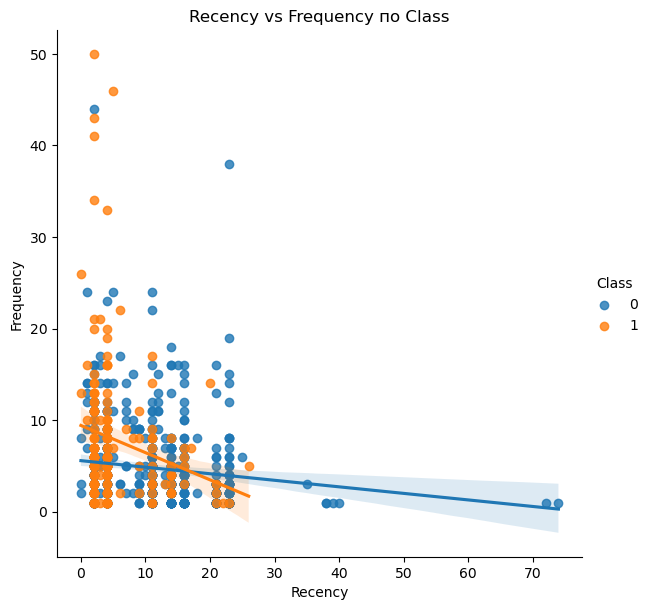

In [34]:
sns.lmplot(
    data=df,
    x='Recency',
    y='Frequency',
    hue='Class',
    height=6
)
plt.title('Recency vs Frequency по Class')
plt.show()

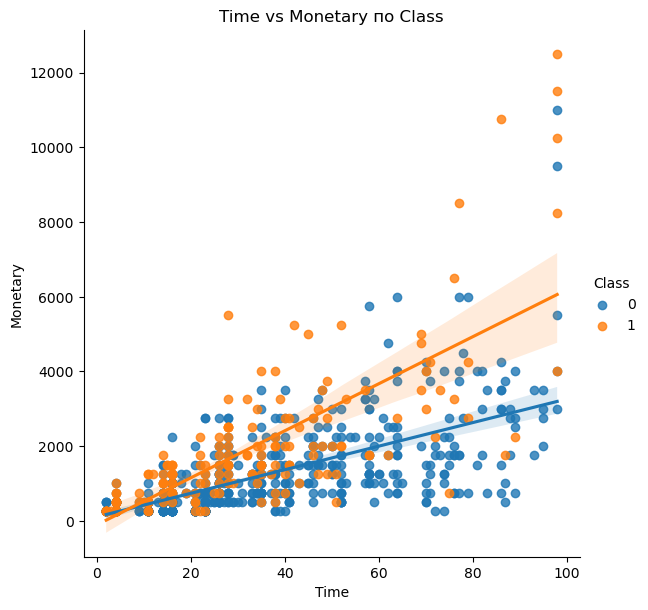

In [35]:
sns.lmplot(
    data=df,
    x='Time',
    y='Monetary',
    hue='Class',
    height=6
)
plt.title('Time vs Monetary по Class')
plt.show()

# 8. Корреляция признаков

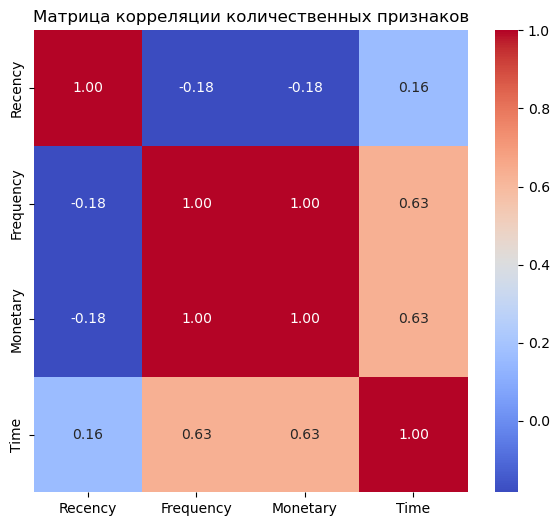

In [25]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='Frequency',
    y='Monetary',
    hue='Class',
    alpha=0.7
)
plt.title("Связь Frequency и Monetary с учетом Class")
plt.xlabel("Частота донорства (Frequency)")
plt.ylabel("Объем сданной крови (Monetary)")
plt.show()